# 01 — Matplotlib: control estético y estructura profesional

Este notebook usa la tabla `cartera_q1_2026_final.parquet`

Pasar de gráficas básicas a gráficas avanzadas y ordenadas para análisis de una cartera de seguros.

In [1]:
# Importamos paquetes base.
# Path permite construir rutas que funcionen en distintos sistemas operativos.
# NumPy y pandas se usan para manipulación de datos.
# Matplotlib da control fino sobre figuras, ejes, títulos, etiquetas y formato.
# FuncFormatter permite convertir números del eje a etiquetas legibles, por ejemplo $1.2M.
# Seaborn se usará principalmente para aplicar un tema visual base consistente.

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

import seaborn as sns

In [2]:
# Configuración global de visualización.
# Estos parámetros afectan las gráficas creadas después de ejecutar esta celda.
# No cambian los datos ni los cálculos; solo modifican la presentación visual.

mpl.rcParams["figure.dpi"] = 120          # Resolución de las figuras en el notebook.
mpl.rcParams["axes.titlesize"] = 14      # Tamaño base de títulos de ejes.
mpl.rcParams["axes.labelsize"] = 11      # Tamaño base de etiquetas de ejes.
mpl.rcParams["xtick.labelsize"] = 10     # Tamaño base de etiquetas del eje X.
mpl.rcParams["ytick.labelsize"] = 10     # Tamaño base de etiquetas del eje Y.
mpl.rcParams["legend.fontsize"] = 10     # Tamaño base de leyendas.

sns.set_theme(
    style="whitegrid",   # Fondo claro con cuadrícula; facilita comparar valores.
    palette="muted",    # Colores moderados, adecuados para reportes analíticos.
    context="notebook"  # Escala visual pensada para notebooks.
)

In [3]:
# Definimos rutas relativas al proyecto.
# El notebook está en /notebooks, por eso usamos .. para regresar a la raíz del proyecto.

DATA_PATH ="datos/cartera_q1_2026_final.parquet"

print(DATA_PATH)

datos/cartera_q1_2026_final.parquet


In [4]:
# Cargamos la tabla maestra.
# Requiere pyarrow o fastparquet; el ambiente propuesto instala pyarrow.

df = pd.read_parquet(DATA_PATH)

print(df.shape)
df.head()

(50000, 52)


,id_poliza,num_poliza,nombre,apellido_paterno,apellido_materno,rfc,edad,sexo,estado_civil,ocupacion,...,comision_est,nivel_riesgo,anio_emision,mes_emision,trimestre,segmento_prima_fijo,cuartil_prima,cod_ramo,anio_poliza,ramo_desde_codigo
0,POL-000001,Vid-21-000001,Gabriela,Moreno,Vega,MOGV020429CG6,24,F,Union libre,Independiente,...,5892.41952,BAJO,2021,11,4,Premium,Q4,VID,2021,Vida
1,POL-000002,Aut-19-000002,Valeria,Torres,Castillo,TOVC020815IA8,23,F,Casado,Contador,...,882.44100,BAJO,2019,8,3,Alta,Q1,AUT,2019,Autos
2,POL-000003,GMM-22-000003,Fernanda,Ramos,Silva,RAFS941018BC1,31,M,Union libre,Ingeniero,...,1995.45984,BAJO,2022,7,3,Premium,Q3,GMM,2022,GMM
3,POL-000004,Vid-19-000004,Silvia,Mendoza,Gutierrez,MESG860204IH8,40,M,Soltero,Arquitecto,...,14002.67088,BAJO,2019,3,1,Premium,Q4,VID,2019,Vida
4,POL-000005,Vid-20-000005,Antonio,Ramos,Castillo,RAAC960722ME2,29,F,Soltero,Independiente,...,6545.88000,MEDIO,2020,11,4,Premium,Q4,VID,2020,Vida


In [5]:
# Revisamos todas las columnas y su tipo de dato.
# Esto ayuda a decidir qué variables pueden usarse como categorías, fechas o valores numéricos.
# object suele indicar texto; category indica variable categórica; datetime64 indica fecha; int/float indican números.

tipos_columnas = (
    df.dtypes
      .astype(str)
      .reset_index()
      .rename(columns={"index": "columna", 0: "tipo_dato"})
)

tipos_columnas

,columna,tipo_dato
0,id_poliza,object
1,num_poliza,object
2,nombre,category
3,apellido_paterno,category
4,apellido_materno,category
5,rfc,object
6,edad,int8
7,sexo,category
8,estado_civil,category
9,ocupacion,category


In [6]:
# Creamos variables auxiliares por si no estuvieran disponibles.
# Esto hace que el notebook sea más robusto ante cambios menores en la tabla.

if "g_edad" not in df.columns and "edad" in df.columns:
    df["g_edad"] = pd.cut(
        df["edad"],
        bins=[0, 30, 45, 60, 100],
        labels=["18-30", "31-45", "46-60", "61+"]
    )

if "mes" not in df.columns and "fecha_emision" in df.columns:
    df["mes"] = df["fecha_emision"].dt.to_period("M").astype(str)

# Validación mínima de columnas necesarias para la sesión.
columnas_clave = [
    "ramo", "edad", "g_edad", "prima_total", "suma_asegurada",
    "n_siniestros", "monto_pagado", "loss_ratio", "estado",
    "nombre_agente", "tipo_agente", "fecha_emision", "mes", "nivel_riesgo"
]

faltantes = [c for c in columnas_clave if c not in df.columns]
print("Columnas faltantes:", faltantes)
print("Columnas disponibles:", len(df.columns))

Columnas faltantes: []
Columnas disponibles: 54


## 1. Diagnóstico visual inicial

Antes de graficar revisaremos la estructura: ramos, niveles de riesgo, fechas y variables monetarias.

In [7]:
# Resumen rápido de composición de cartera.
# Agrupamos por ramo para comparar tamaño, volumen de prima y siniestralidad agregada.
# observed=False conserva el comportamiento explícito para variables categóricas.

resumen_ramo = (
    df.groupby("ramo", observed=False)
      .agg(
          polizas=("id_poliza", "count"),          # Número de pólizas por ramo.
          prima_total=("prima_total", "sum"),      # Prima acumulada por ramo.
          prima_promedio=("prima_total", "mean"),  # Prima promedio por póliza.
          siniestros=("n_siniestros", "sum"),      # Conteo total de siniestros.
          monto_pagado=("monto_pagado", "sum")     # Monto pagado total.
      )
      .sort_values("prima_total", ascending=False) # Ordenamos de mayor a menor prima.
)

# style.format cambia solo la visualización en Jupyter; no convierte los datos a texto.
# {:,.0f} significa: separador de miles con coma y cero decimales.
resumen_ramo.style.format({
    "polizas": "{:,.0f}",
    "prima_total": "{:,.0f}",
    "prima_promedio": "{:,.0f}",
    "siniestros": "{:,.0f}",
    "monto_pagado": "{:,.0f}",
})

,polizas,prima_total,prima_promedio,siniestros,monto_pagado
ramo,,,,,
GMM,"22,531","731,022,322","32,445","8,146","96,912,286"
Vida,"7,510","454,332,123","60,497","2,731","30,878,141"
Autos,"14,752","253,823,506","17,206","5,290","64,499,502"
Accidentes Personales,"5,207","24,980,679","4,798","1,833","22,311,397"


## 2. De gráfica básica a gráfica presentable

La mejora estética no consiste solo en cambiar colores. Se mejora el mensaje cuando se ordenan categorías, se agregan unidades, se formatean ejes y se reduce ruido visual.

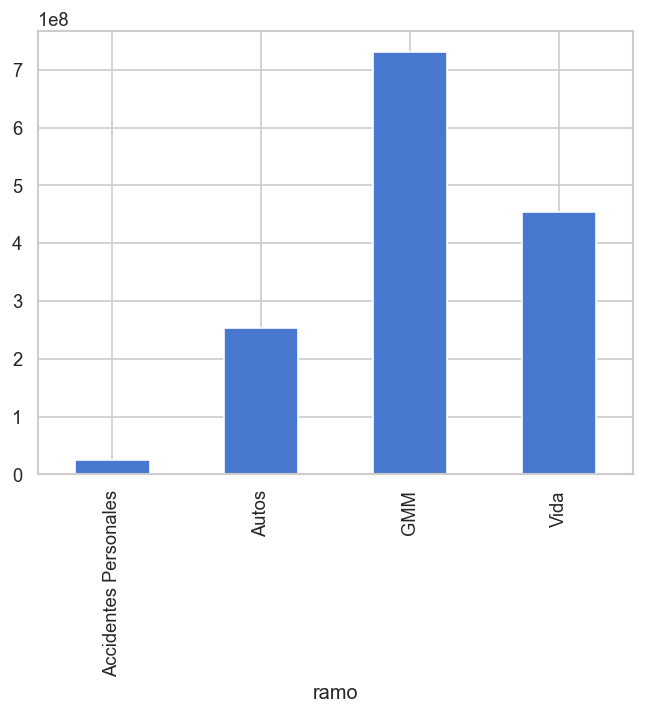

In [8]:
# Versión básica: funciona, pero comunica poco.

df.groupby("ramo", observed=False)["prima_total"].sum().plot(kind="bar")
plt.show()

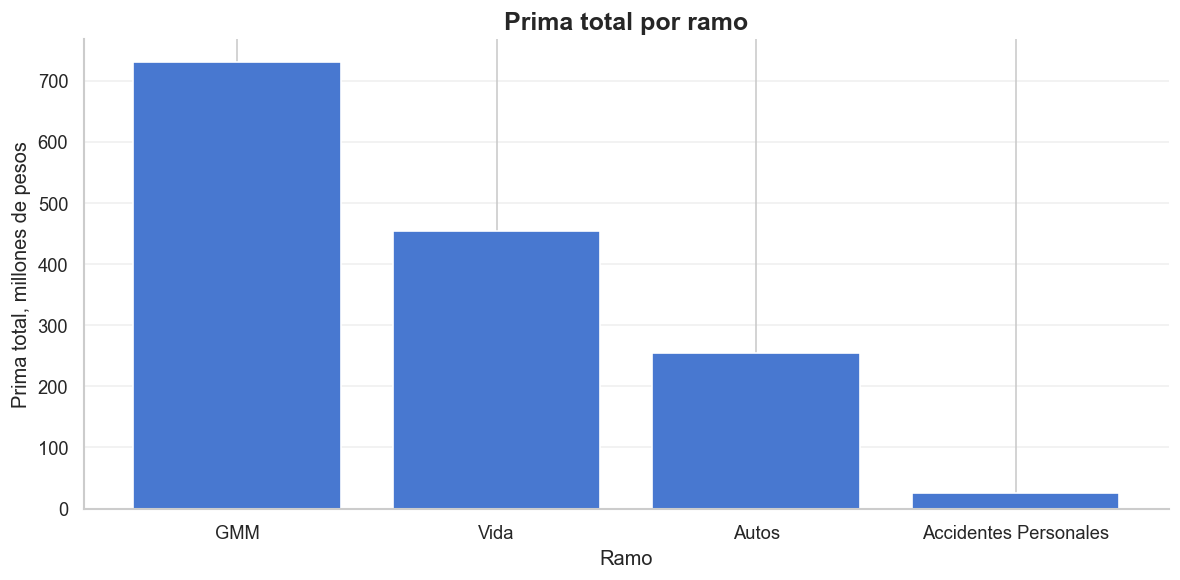

In [9]:
# Versión mejorada con Matplotlib.
# Se ordenan los ramos, se usa unidad en millones y se formatea el eje.

prima_ramo = (
    df.groupby("ramo", as_index=False, observed=False)["prima_total"]
      .sum()
      .sort_values("prima_total", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    prima_ramo["ramo"].astype(str),
    prima_ramo["prima_total"] / 1_000_000
)

ax.set_title("Prima total por ramo", fontsize=15, fontweight="bold")
ax.set_xlabel("Ramo")
ax.set_ylabel("Prima total, millones de pesos")
ax.grid(axis="y", alpha=0.30)

# Quitamos bordes que no aportan información.
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 3. Formato profesional de ejes

En reportes, los ejes deben ser interpretables sin explicación verbal. Para montos, porcentajes y fechas se usa formato específico y profesional.

In [10]:
# Funciones de formato reutilizables.
# Matplotlib llama estas funciones al dibujar cada marca del eje.
# El parámetro pos lo envía Matplotlib internamente; no necesitamos usarlo.

def formato_miles(x, pos):
    """Convierte un monto a miles: 25000 -> $25k."""
    return f"${x/1_000:,.0f}k"


def formato_millones(x, pos):
    """Convierte un monto a millones: 2500000 -> $2.5M."""
    return f"${x/1_000_000:,.1f}M"

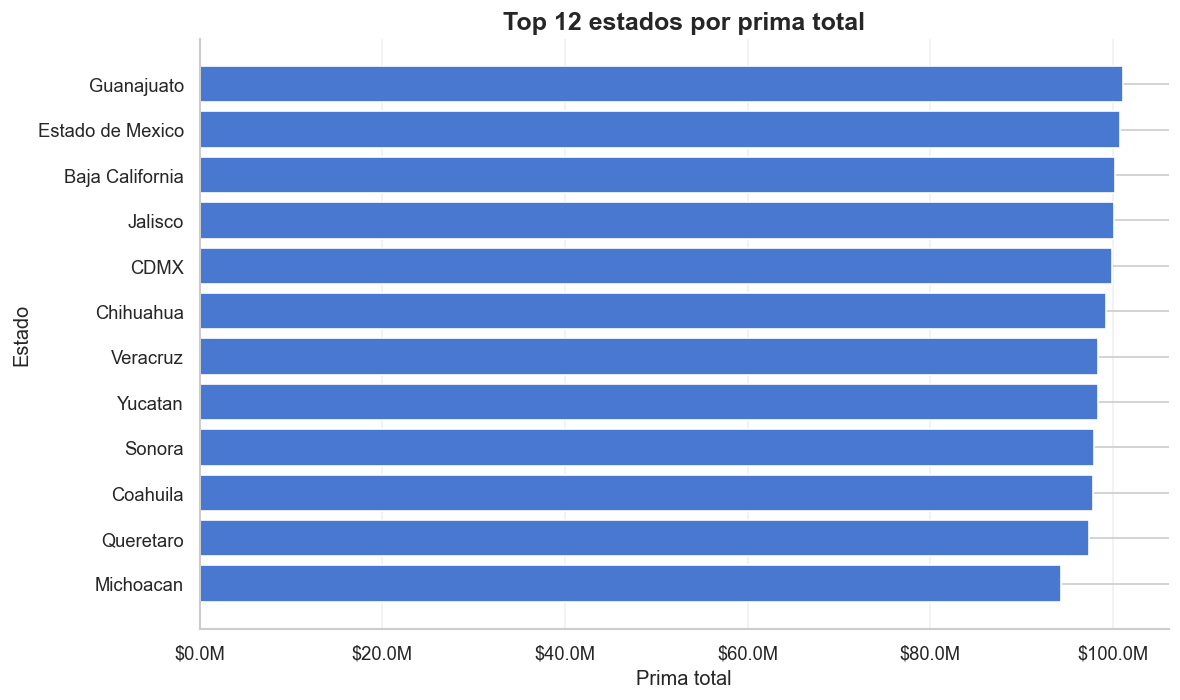

In [11]:
# Top 12 estados por prima total.
# Usamos barras horizontales porque los nombres de estados son más legibles en el eje Y.

prima_estado = (
    df.groupby("estado", as_index=False, observed=False)["prima_total"]
      .sum()
      .sort_values("prima_total", ascending=False)
      .head(12)  # Tomamos solo los 12 mayores para evitar una gráfica saturada.
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    prima_estado["estado"].astype(str),
    prima_estado["prima_total"]
)

# Invertimos el eje para que el mayor quede arriba, como en un ranking.
ax.invert_yaxis()

ax.set_title("Top 12 estados por prima total", fontsize=15, fontweight="bold")
ax.set_xlabel("Prima total")
ax.set_ylabel("Estado")
ax.xaxis.set_major_formatter(FuncFormatter(formato_millones))
ax.grid(axis="x", alpha=0.30)  # Cuadrícula vertical para comparar longitud de barras.

# Quitamos bordes que no aportan información.
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 4. Subplots: composición de varias vistas

Los subplots son útiles para un tablero exploratorio.

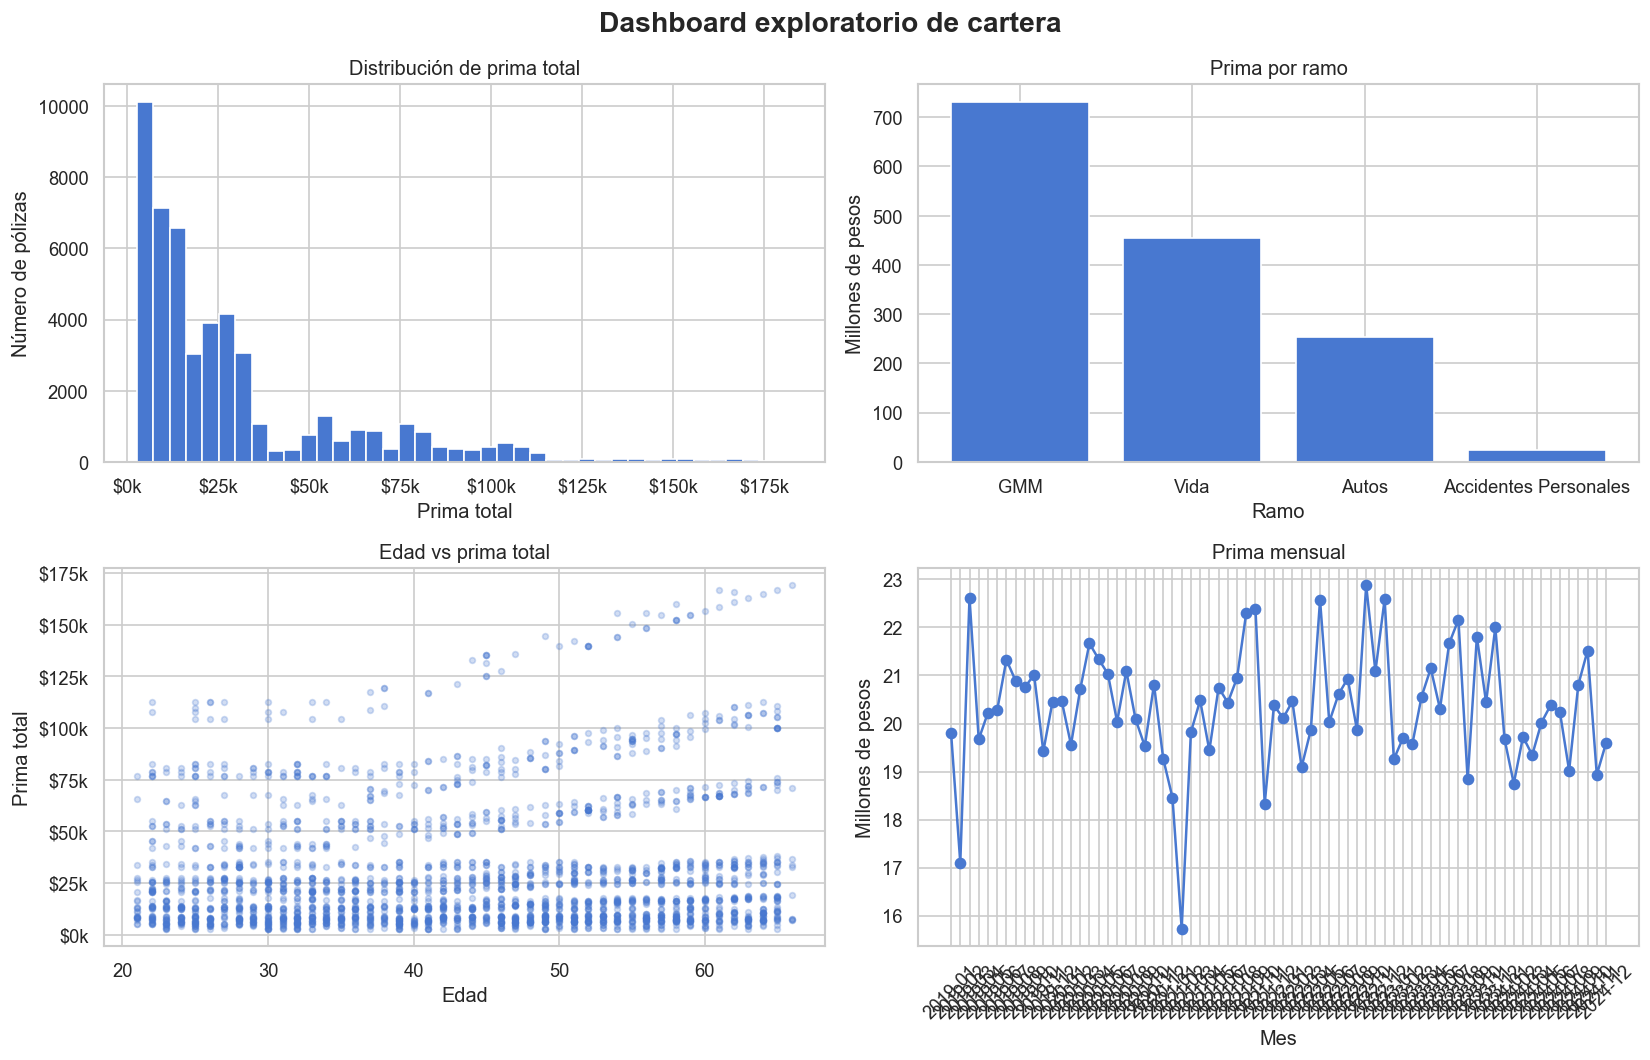

In [12]:
# Creamos una muestra para evitar que el scatterplot se sature.

muestra = df.sample(min(2500, len(df)), random_state=123)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1) Distribución de prima.
axes[0, 0].hist(df["prima_total"], bins=40)
axes[0, 0].set_title("Distribución de prima total")
axes[0, 0].set_xlabel("Prima total")
axes[0, 0].set_ylabel("Número de pólizas")
axes[0, 0].xaxis.set_major_formatter(FuncFormatter(formato_miles))

# 2) Prima por ramo.
axes[0, 1].bar(prima_ramo["ramo"].astype(str), prima_ramo["prima_total"] / 1_000_000)
axes[0, 1].set_title("Prima por ramo")
axes[0, 1].set_xlabel("Ramo")
axes[0, 1].set_ylabel("Millones de pesos")

# 3) Relación edad vs prima.
axes[1, 0].scatter(muestra["edad"], muestra["prima_total"], alpha=0.25, s=12)
axes[1, 0].set_title("Edad vs prima total")
axes[1, 0].set_xlabel("Edad")
axes[1, 0].set_ylabel("Prima total")
axes[1, 0].yaxis.set_major_formatter(FuncFormatter(formato_miles))

# 4) Tendencia mensual de prima emitida.
por_mes_total = (
    df.groupby("mes", as_index=False)["prima_total"]
      .sum()
      .sort_values("mes")
)

axes[1, 1].plot(por_mes_total["mes"], por_mes_total["prima_total"] / 1_000_000, marker="o")
axes[1, 1].set_title("Prima mensual")
axes[1, 1].set_xlabel("Mes")
axes[1, 1].set_ylabel("Millones de pesos")
axes[1, 1].tick_params(axis="x", rotation=45)

fig.suptitle("Dashboard exploratorio de cartera", fontsize=17, fontweight="bold")

plt.tight_layout()
plt.show()

## 4.1. Comparación de formatos para el eje X mensual

Las siguientes celdas usan la misma serie mensual. La única diferencia importante es cómo se controla el eje X.

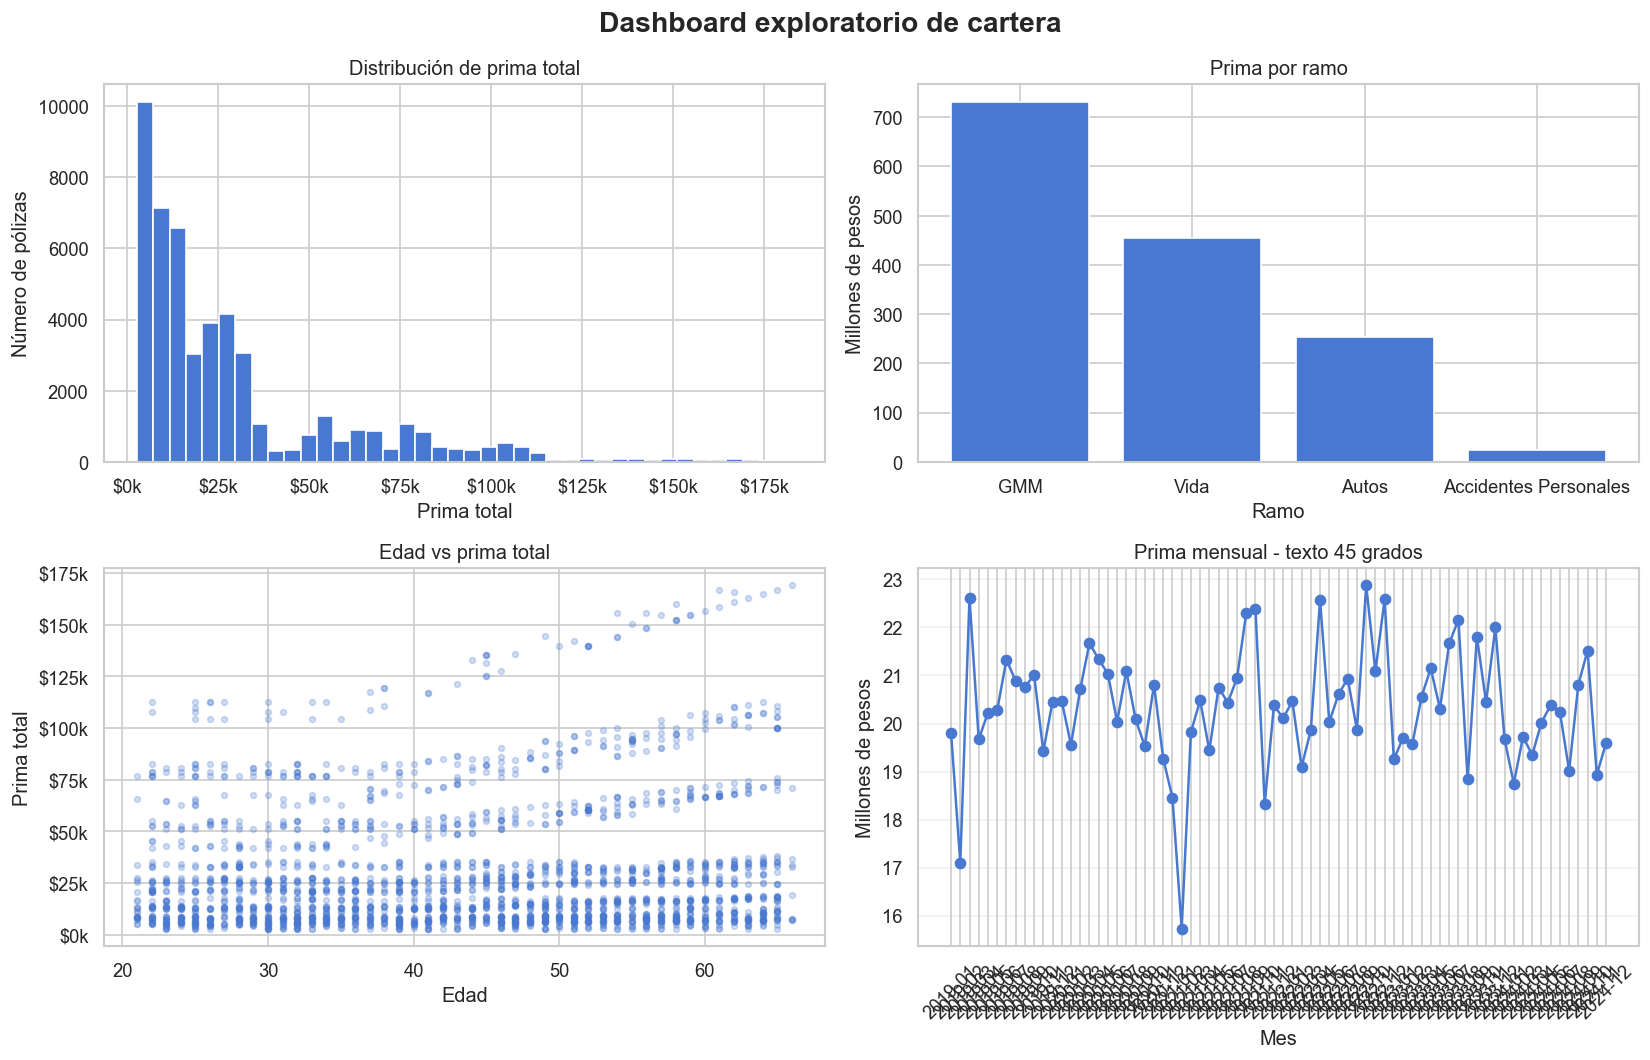

In [13]:
# Versión A: eje X como texto, con rotación básica.
# La celda repite el dashboard completo y solo cambia la gráfica 4.

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1) Distribución de prima.
axes[0, 0].hist(df["prima_total"], bins=40)
axes[0, 0].set_title("Distribución de prima total")
axes[0, 0].set_xlabel("Prima total")
axes[0, 0].set_ylabel("Número de pólizas")
axes[0, 0].xaxis.set_major_formatter(FuncFormatter(formato_miles))

# 2) Prima por ramo.
axes[0, 1].bar(prima_ramo["ramo"].astype(str), prima_ramo["prima_total"] / 1_000_000)
axes[0, 1].set_title("Prima por ramo")
axes[0, 1].set_xlabel("Ramo")
axes[0, 1].set_ylabel("Millones de pesos")

# 3) Relación edad vs prima.
axes[1, 0].scatter(muestra["edad"], muestra["prima_total"], alpha=0.25, s=12)
axes[1, 0].set_title("Edad vs prima total")
axes[1, 0].set_xlabel("Edad")
axes[1, 0].set_ylabel("Prima total")
axes[1, 0].yaxis.set_major_formatter(FuncFormatter(formato_miles))

# 4) Tendencia mensual de prima emitida.
axes[1, 1].plot(por_mes_total["mes"], por_mes_total["prima_total"] / 1_000_000, marker="o")
axes[1, 1].set_title("Prima mensual - texto 45 grados")
axes[1, 1].set_xlabel("Mes")
axes[1, 1].set_ylabel("Millones de pesos")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].grid(axis="y", alpha=0.30)

fig.suptitle("Dashboard exploratorio de cartera", fontsize=17, fontweight="bold")

plt.tight_layout()
plt.show()

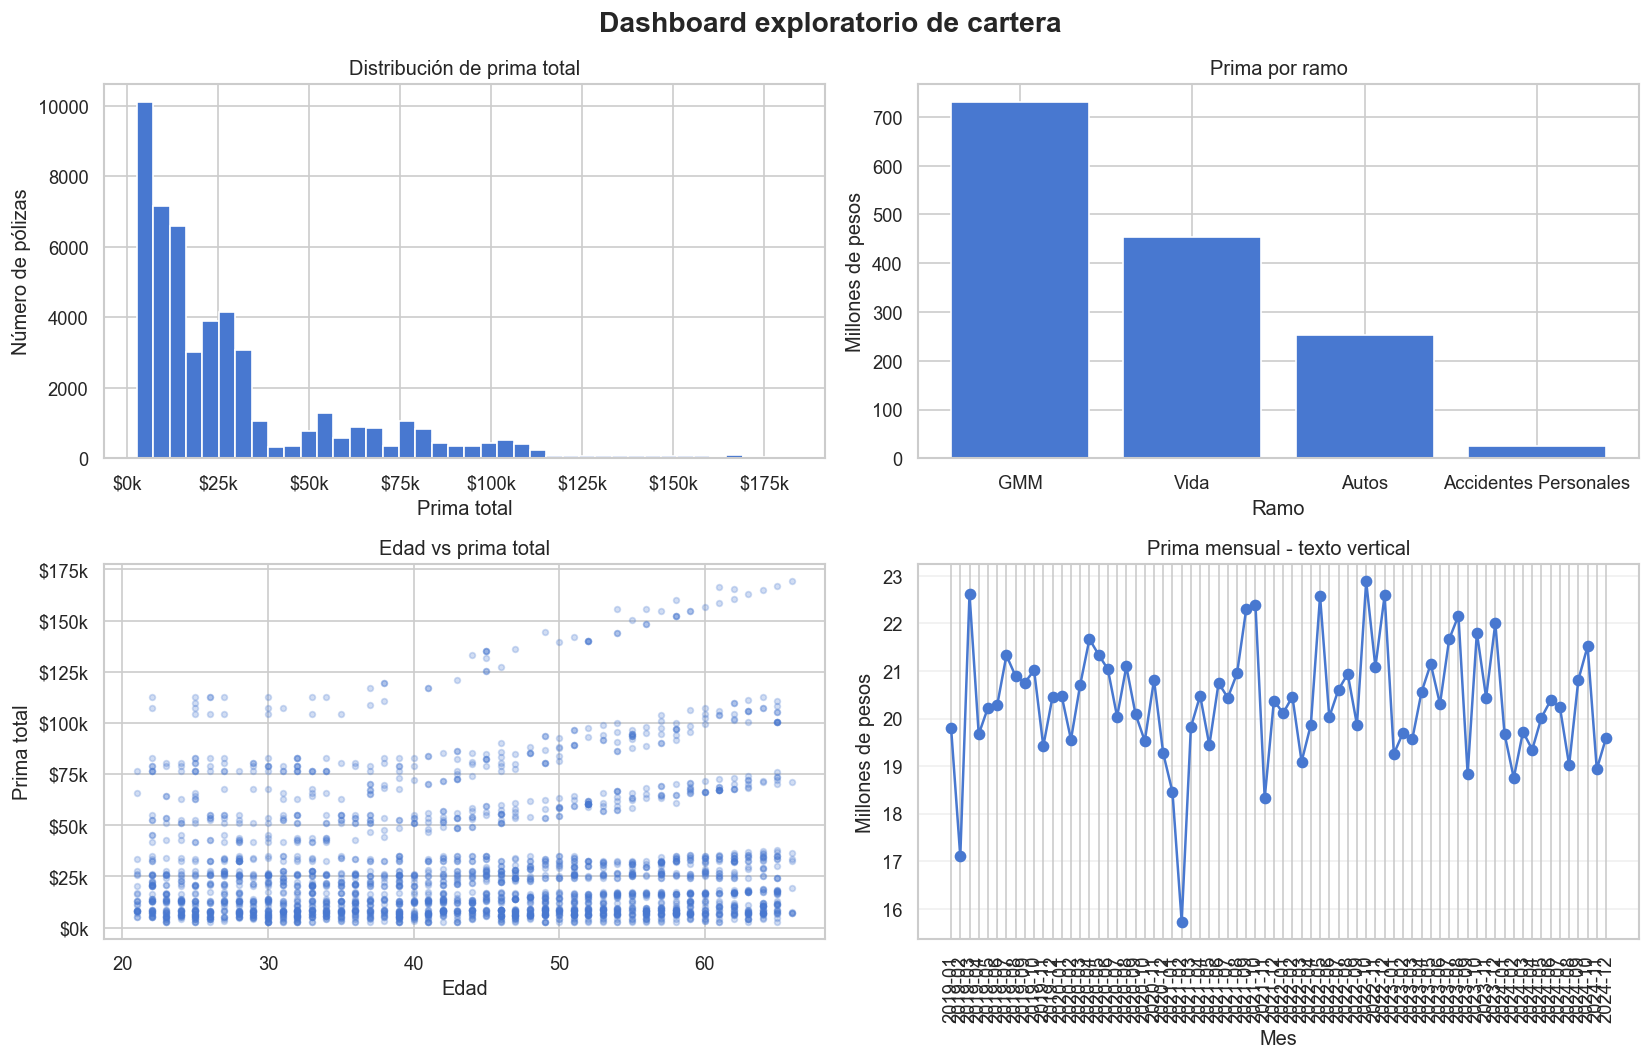

In [14]:
# Versión B: eje X como texto, rotación vertical.
# La celda repite el dashboard completo y solo cambia la gráfica 4.

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1) Distribución de prima.
axes[0, 0].hist(df["prima_total"], bins=40)
axes[0, 0].set_title("Distribución de prima total")
axes[0, 0].set_xlabel("Prima total")
axes[0, 0].set_ylabel("Número de pólizas")
axes[0, 0].xaxis.set_major_formatter(FuncFormatter(formato_miles))

# 2) Prima por ramo.
axes[0, 1].bar(prima_ramo["ramo"].astype(str), prima_ramo["prima_total"] / 1_000_000)
axes[0, 1].set_title("Prima por ramo")
axes[0, 1].set_xlabel("Ramo")
axes[0, 1].set_ylabel("Millones de pesos")

# 3) Relación edad vs prima.
axes[1, 0].scatter(muestra["edad"], muestra["prima_total"], alpha=0.25, s=12)
axes[1, 0].set_title("Edad vs prima total")
axes[1, 0].set_xlabel("Edad")
axes[1, 0].set_ylabel("Prima total")
axes[1, 0].yaxis.set_major_formatter(FuncFormatter(formato_miles))

# 4) Tendencia mensual de prima emitida.
axes[1, 1].plot(por_mes_total["mes"], por_mes_total["prima_total"] / 1_000_000, marker="o")
axes[1, 1].set_title("Prima mensual - texto vertical")
axes[1, 1].set_xlabel("Mes")
axes[1, 1].set_ylabel("Millones de pesos")
axes[1, 1].tick_params(axis="x", rotation=90)
axes[1, 1].grid(axis="y", alpha=0.30)

fig.suptitle("Dashboard exploratorio de cartera", fontsize=17, fontweight="bold")

plt.tight_layout()
plt.show()

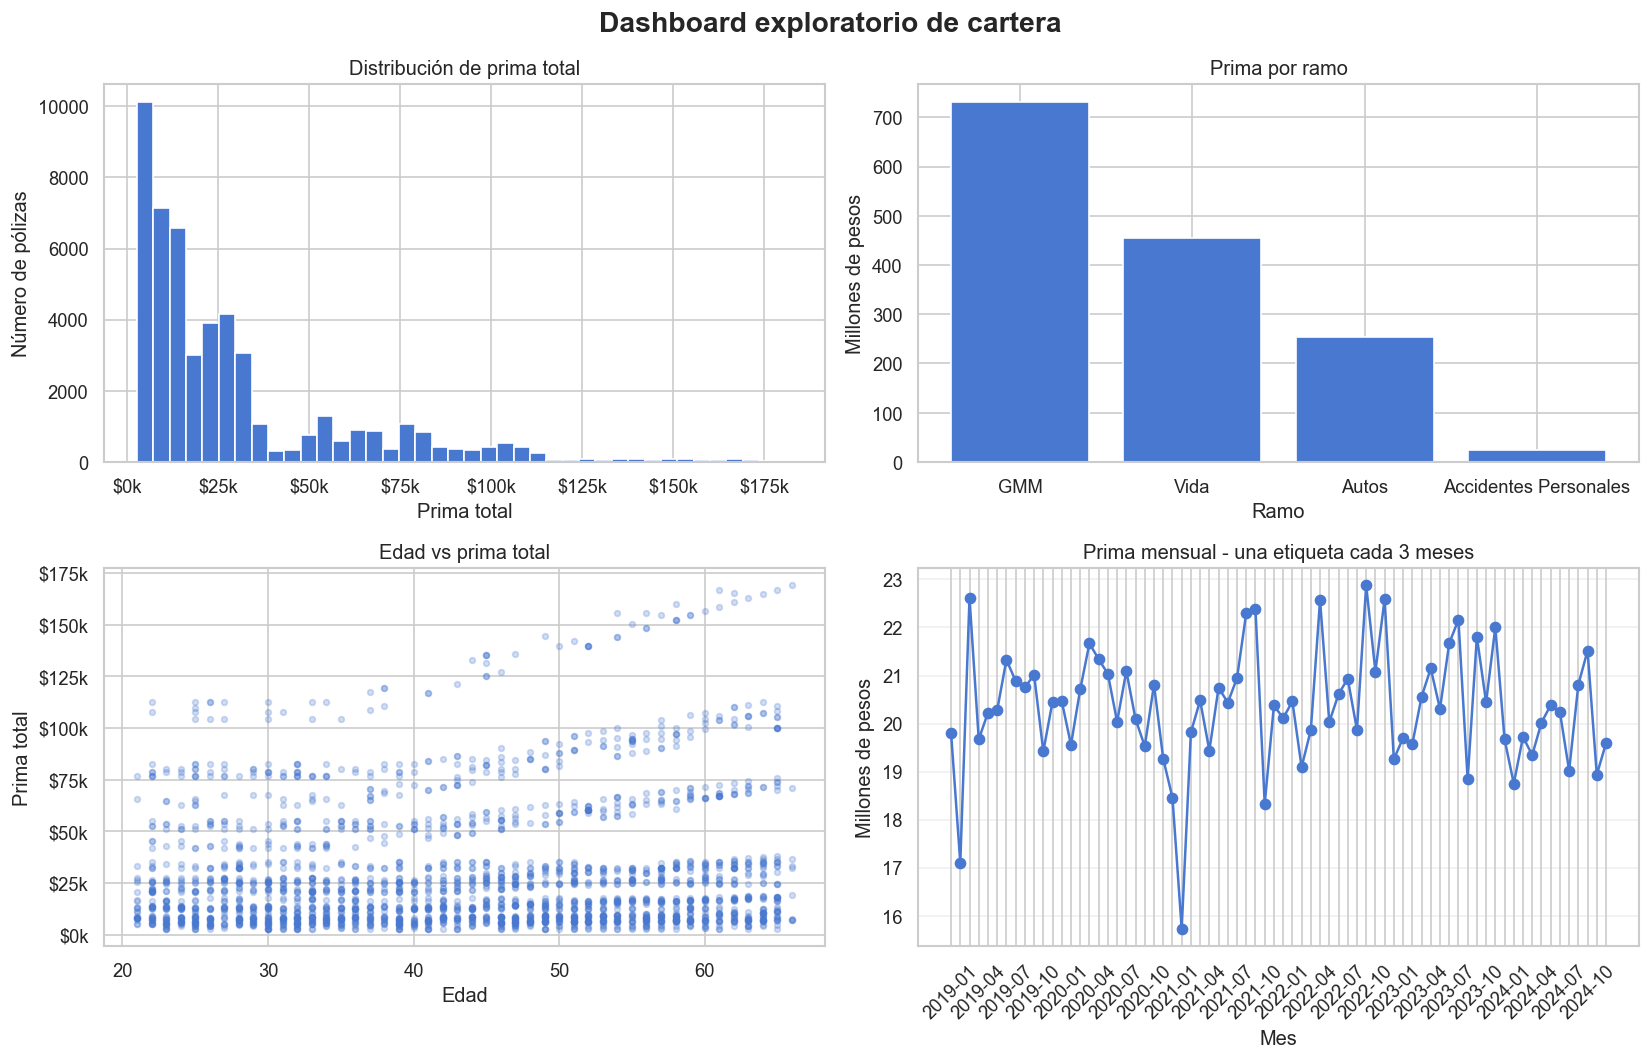

In [15]:
# Versión C: eje X como texto, mostrando una etiqueta cada 3 meses.
# La celda repite el dashboard completo y solo cambia la gráfica 4.

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1) Distribución de prima.
axes[0, 0].hist(df["prima_total"], bins=40)
axes[0, 0].set_title("Distribución de prima total")
axes[0, 0].set_xlabel("Prima total")
axes[0, 0].set_ylabel("Número de pólizas")
axes[0, 0].xaxis.set_major_formatter(FuncFormatter(formato_miles))

# 2) Prima por ramo.
axes[0, 1].bar(prima_ramo["ramo"].astype(str), prima_ramo["prima_total"] / 1_000_000)
axes[0, 1].set_title("Prima por ramo")
axes[0, 1].set_xlabel("Ramo")
axes[0, 1].set_ylabel("Millones de pesos")

# 3) Relación edad vs prima.
axes[1, 0].scatter(muestra["edad"], muestra["prima_total"], alpha=0.25, s=12)
axes[1, 0].set_title("Edad vs prima total")
axes[1, 0].set_xlabel("Edad")
axes[1, 0].set_ylabel("Prima total")
axes[1, 0].yaxis.set_major_formatter(FuncFormatter(formato_miles))

# 4) Tendencia mensual de prima emitida.
axes[1, 1].plot(por_mes_total["mes"], por_mes_total["prima_total"] / 1_000_000, marker="o")
axes[1, 1].set_title("Prima mensual - una etiqueta cada 3 meses")
axes[1, 1].set_xlabel("Mes")
axes[1, 1].set_ylabel("Millones de pesos")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].grid(axis="y", alpha=0.30)

for i, label in enumerate(axes[1, 1].get_xticklabels()):
    if i % 3 != 0:
        label.set_visible(False)

fig.suptitle("Dashboard exploratorio de cartera", fontsize=17, fontweight="bold")

plt.tight_layout()
plt.show()

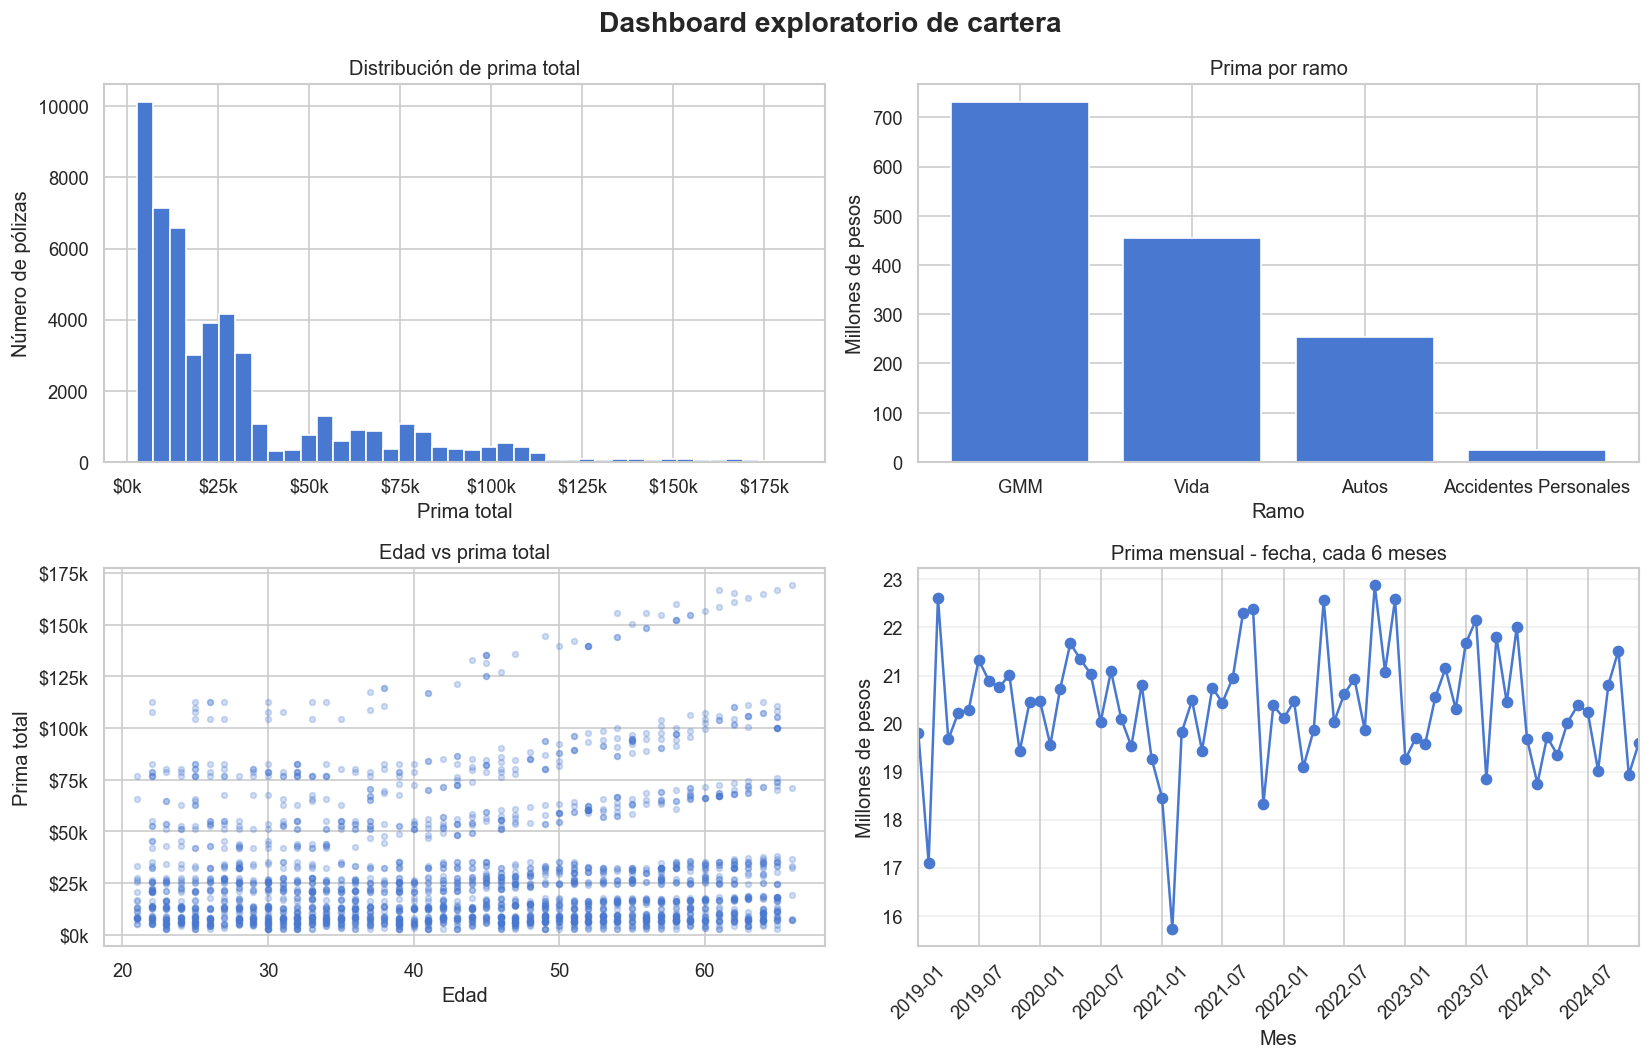

In [16]:
# Versión D: eje X como fecha real, mostrando una marca cada 6 meses.
# La celda repite el dashboard completo y solo cambia la gráfica 4.

import matplotlib.dates as mdates

por_mes_total_fecha = por_mes_total.copy()
por_mes_total_fecha["mes_fecha"] = pd.to_datetime(por_mes_total_fecha["mes"])

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1) Distribución de prima.
axes[0, 0].hist(df["prima_total"], bins=40)
axes[0, 0].set_title("Distribución de prima total")
axes[0, 0].set_xlabel("Prima total")
axes[0, 0].set_ylabel("Número de pólizas")
axes[0, 0].xaxis.set_major_formatter(FuncFormatter(formato_miles))

# 2) Prima por ramo.
axes[0, 1].bar(prima_ramo["ramo"].astype(str), prima_ramo["prima_total"] / 1_000_000)
axes[0, 1].set_title("Prima por ramo")
axes[0, 1].set_xlabel("Ramo")
axes[0, 1].set_ylabel("Millones de pesos")

# 3) Relación edad vs prima.
axes[1, 0].scatter(muestra["edad"], muestra["prima_total"], alpha=0.25, s=12)
axes[1, 0].set_title("Edad vs prima total")
axes[1, 0].set_xlabel("Edad")
axes[1, 0].set_ylabel("Prima total")
axes[1, 0].yaxis.set_major_formatter(FuncFormatter(formato_miles))

# 4) Tendencia mensual de prima emitida.
axes[1, 1].plot(
    por_mes_total_fecha["mes_fecha"],
    por_mes_total_fecha["prima_total"] / 1_000_000,
    marker="o"
)
axes[1, 1].set_title("Prima mensual - fecha, cada 6 meses")
axes[1, 1].set_xlabel("Mes")
axes[1, 1].set_ylabel("Millones de pesos")
axes[1, 1].set_xlim(
    por_mes_total_fecha["mes_fecha"].min(),
    por_mes_total_fecha["mes_fecha"].max()
)
axes[1, 1].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].grid(axis="y", alpha=0.30)

fig.suptitle("Dashboard exploratorio de cartera", fontsize=17, fontweight="bold")

plt.tight_layout()
plt.show()

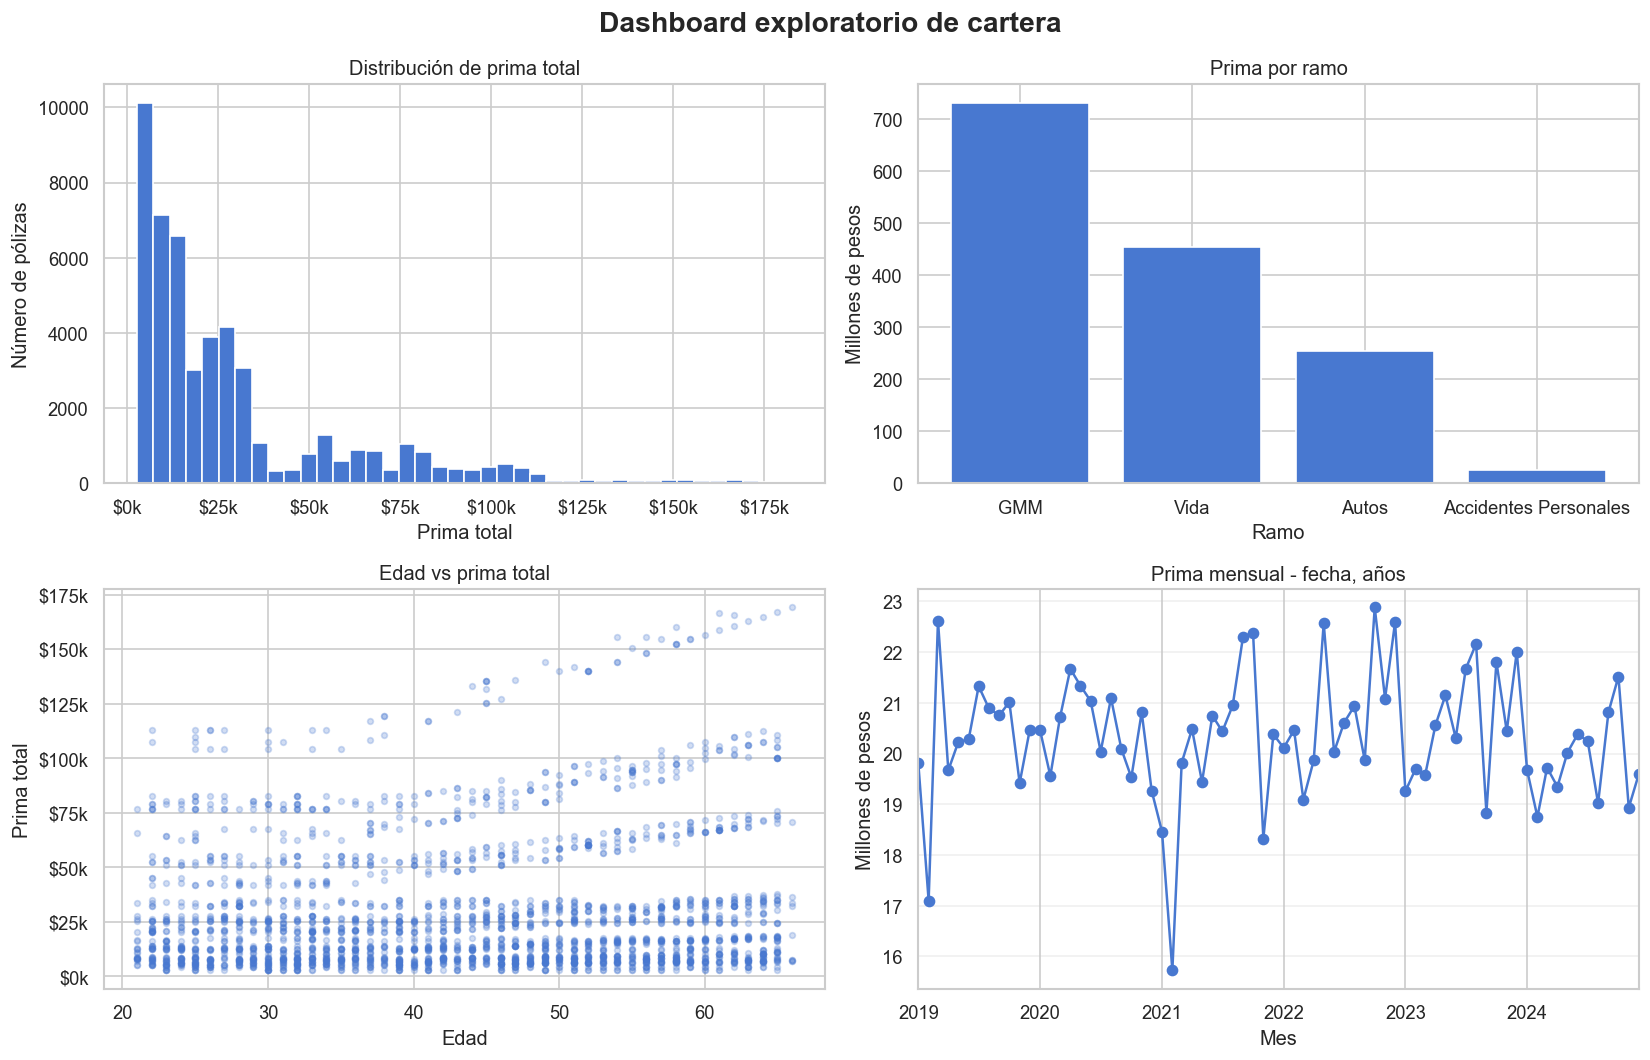

In [17]:
# Versión E: eje X como fecha real, mostrando años.
# Esta fue la versión más legible al revisar la gráfica completa de 4 paneles.

import matplotlib.dates as mdates

por_mes_total_fecha = por_mes_total.copy()
por_mes_total_fecha["mes_fecha"] = pd.to_datetime(por_mes_total_fecha["mes"])

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1) Distribución de prima.
axes[0, 0].hist(df["prima_total"], bins=40)
axes[0, 0].set_title("Distribución de prima total")
axes[0, 0].set_xlabel("Prima total")
axes[0, 0].set_ylabel("Número de pólizas")
axes[0, 0].xaxis.set_major_formatter(FuncFormatter(formato_miles))

# 2) Prima por ramo.
axes[0, 1].bar(prima_ramo["ramo"].astype(str), prima_ramo["prima_total"] / 1_000_000)
axes[0, 1].set_title("Prima por ramo")
axes[0, 1].set_xlabel("Ramo")
axes[0, 1].set_ylabel("Millones de pesos")

# 3) Relación edad vs prima.
axes[1, 0].scatter(muestra["edad"], muestra["prima_total"], alpha=0.25, s=12)
axes[1, 0].set_title("Edad vs prima total")
axes[1, 0].set_xlabel("Edad")
axes[1, 0].set_ylabel("Prima total")
axes[1, 0].yaxis.set_major_formatter(FuncFormatter(formato_miles))

# 4) Tendencia mensual de prima emitida.
axes[1, 1].plot(
    por_mes_total_fecha["mes_fecha"],
    por_mes_total_fecha["prima_total"] / 1_000_000,
    marker="o"
)
axes[1, 1].set_title("Prima mensual - fecha, años")
axes[1, 1].set_xlabel("Mes")
axes[1, 1].set_ylabel("Millones de pesos")
axes[1, 1].set_xlim(
    por_mes_total_fecha["mes_fecha"].min(),
    por_mes_total_fecha["mes_fecha"].max()
)
axes[1, 1].xaxis.set_major_locator(mdates.YearLocator())
axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1, 1].tick_params(axis="x", rotation=0)
axes[1, 1].grid(axis="y", alpha=0.30)

fig.suptitle("Dashboard exploratorio de cartera", fontsize=17, fontweight="bold")

plt.tight_layout()
plt.show()

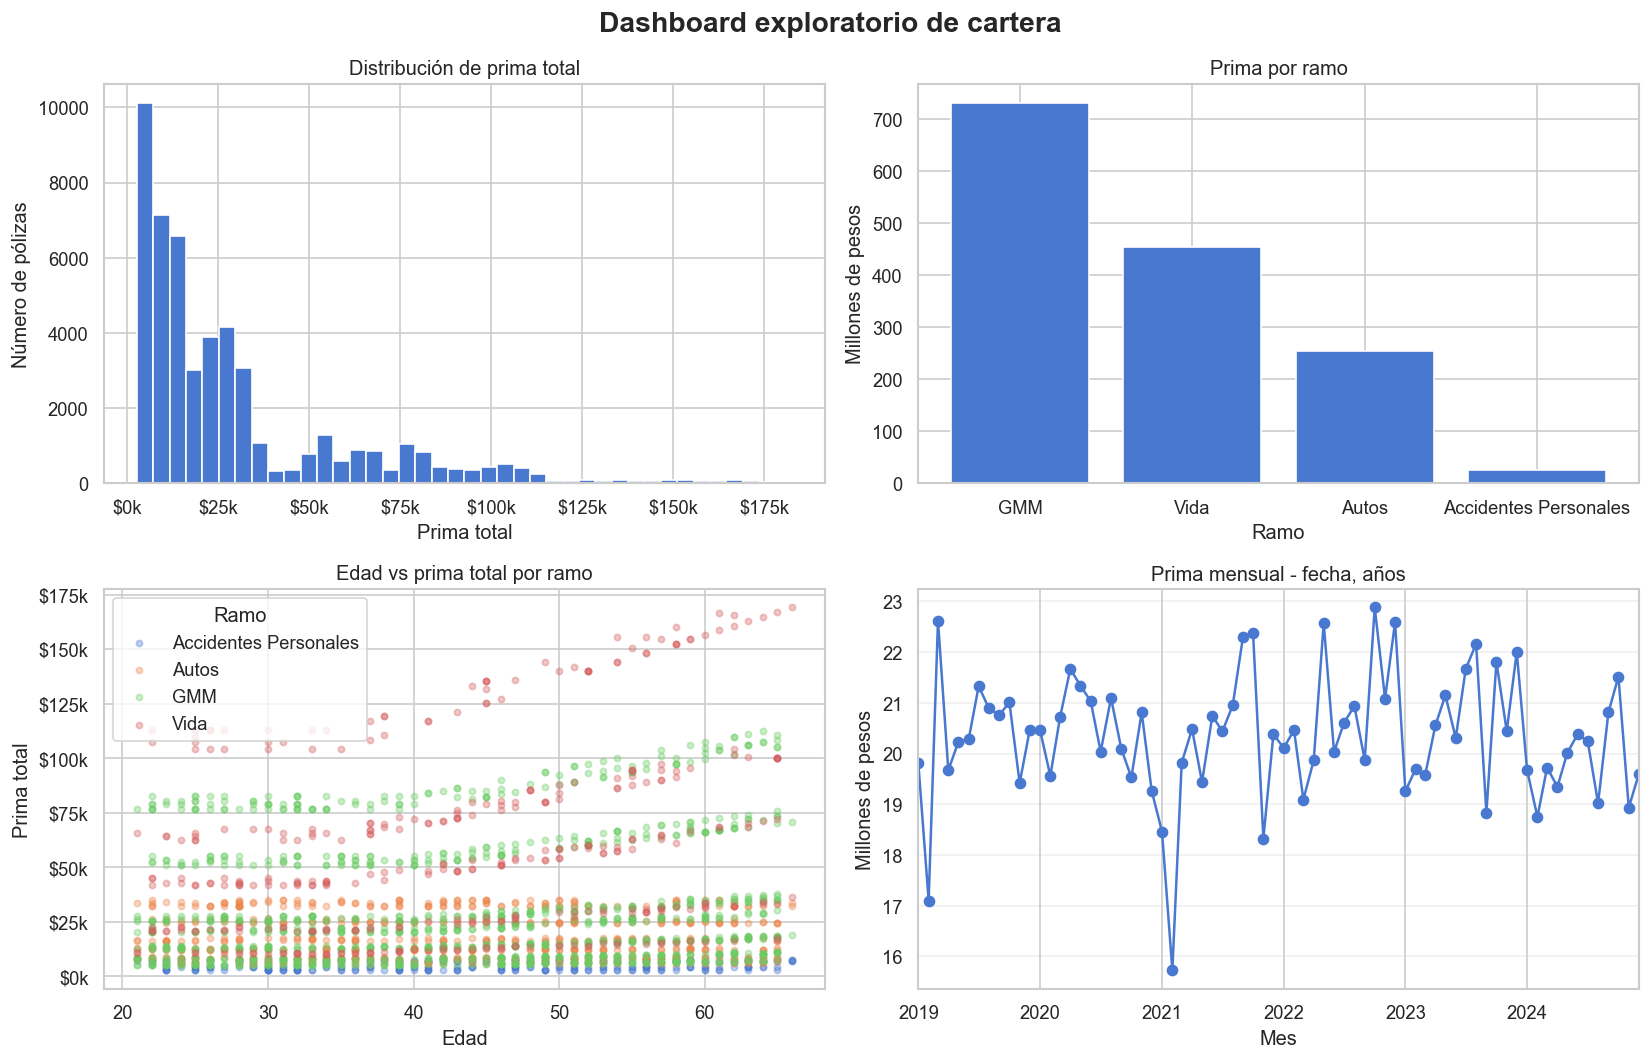

In [18]:
# Versión final: dashboard con Edad vs prima coloreada por ramo.
# Se duplica la versión anterior y solo se modifica la gráfica 3.
# Objetivo: separar visualmente las nubes de puntos para distinguir patrones por ramo.

import matplotlib.dates as mdates

# Convertimos el mes de texto a fecha real para que Matplotlib trate el eje como temporal.
por_mes_total_fecha = por_mes_total.copy()
por_mes_total_fecha["mes_fecha"] = pd.to_datetime(por_mes_total_fecha["mes"])

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1) Distribución de prima.
# bins=40 divide el rango de primas en 40 intervalos; más bins dan más detalle, pero más ruido.
axes[0, 0].hist(df["prima_total"], bins=40)
axes[0, 0].set_title("Distribución de prima total")
axes[0, 0].set_xlabel("Prima total")
axes[0, 0].set_ylabel("Número de pólizas")
axes[0, 0].xaxis.set_major_formatter(FuncFormatter(formato_miles))

# 2) Prima por ramo.
# Usamos prima_ramo ya ordenado para comparar los ramos de mayor a menor prima.
axes[0, 1].bar(prima_ramo["ramo"].astype(str), prima_ramo["prima_total"] / 1_000_000)
axes[0, 1].set_title("Prima por ramo")
axes[0, 1].set_xlabel("Ramo")
axes[0, 1].set_ylabel("Millones de pesos")

# 3) Relación edad vs prima, diferenciando ramos por color.
# groupby divide la muestra en subconjuntos; cada subconjunto se dibuja con una etiqueta distinta.
# alpha=0.35 agrega transparencia para que la sobreposición de puntos sea menos pesada.
# s=14 controla el tamaño del punto.
for ramo, datos_ramo in muestra.groupby("ramo", observed=False):
    axes[1, 0].scatter(
        datos_ramo["edad"],
        datos_ramo["prima_total"],
        alpha=0.35,
        s=14,
        label=str(ramo)
    )

axes[1, 0].set_title("Edad vs prima total por ramo")
axes[1, 0].set_xlabel("Edad")
axes[1, 0].set_ylabel("Prima total")
axes[1, 0].yaxis.set_major_formatter(FuncFormatter(formato_miles))
axes[1, 0].legend(title="Ramo", loc="upper left", frameon=True)

# 4) Tendencia mensual de prima emitida.
axes[1, 1].plot(
    por_mes_total_fecha["mes_fecha"],
    por_mes_total_fecha["prima_total"] / 1_000_000,
    marker="o"
)
axes[1, 1].set_title("Prima mensual - fecha, años")
axes[1, 1].set_xlabel("Mes")
axes[1, 1].set_ylabel("Millones de pesos")
axes[1, 1].set_xlim(
    por_mes_total_fecha["mes_fecha"].min(),
    por_mes_total_fecha["mes_fecha"].max()
)
axes[1, 1].xaxis.set_major_locator(mdates.YearLocator())      # Una marca principal por año.
axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter("%Y")) # Mostrar solo el año.
axes[1, 1].tick_params(axis="x", rotation=0)                  # Etiquetas horizontales.
axes[1, 1].grid(axis="y", alpha=0.30)                         # Guías horizontales suaves.

fig.suptitle("Dashboard exploratorio de cartera", fontsize=17, fontweight="bold")

plt.tight_layout()
plt.show()

## 5. Buenas prácticas con Matplotlib

Checklist rápido:

- Usar `fig, ax = plt.subplots()` para tener control explícito.
- Definir tamaño de figura antes de graficar.
- Ordenar categorías cuando se comparan montos o frecuencias.
- Usar unidades en los ejes.
- Formatear moneda, miles, millones o porcentajes.
- Reducir bordes, grids o leyendas innecesarias.
- Usar `plt.tight_layout()` para evitar cortes.

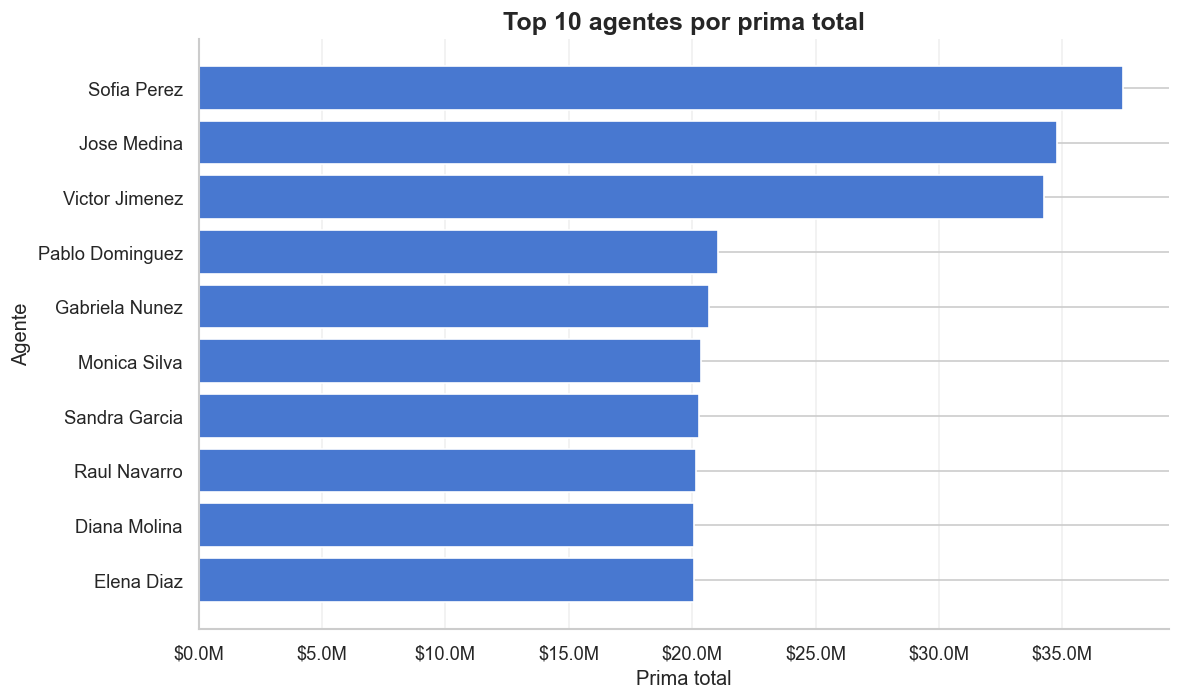

In [19]:
# Ejercicio breve:
# Construye una gráfica en Matplotlib que responda:
# ¿Qué agentes concentran mayor prima total?
# Sugerencia: agrupa por nombre_agente, ordena, toma top 10 y usa barras horizontales.

prima_agente = (
    df.groupby("nombre_agente", as_index=False)["prima_total"]
      .sum()
      .sort_values("prima_total", ascending=False)
      .head(10)
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(prima_agente["nombre_agente"], prima_agente["prima_total"])
ax.invert_yaxis()

ax.set_title("Top 10 agentes por prima total", fontsize=15, fontweight="bold")
ax.set_xlabel("Prima total")
ax.set_ylabel("Agente")
ax.xaxis.set_major_formatter(FuncFormatter(formato_millones))
ax.grid(axis="x", alpha=0.30)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()